# Importing required libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns, ipywidgets as widgets
import random,uuid,io,joblib

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import *
from skimage.feature import hog
from PIL import Image
from skimage.color import rgb2gray

# Acquiring the dataset and manupulating it for computational efficiency

In [2]:
resize=(128,128) # Ensures that every image is reduced to 64*64=4096 feature vactors
dataset= "/kaggle/input/cat-and-dog-images/DataSet" 
classification_rule={'Cats':0,'Dogs':1} # Classification rule of the images

In [3]:
# Function for extracting the HOG feature
#=============================================
def extract_hog_features(image):
    image_resize=image.resize(resize)
    gray_image=image_resize.convert('L')
    features,_=hog(gray_image, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), block_norm="L2-Hys", visualize=True)
    return features

In [4]:
# Function of loading all the images as a vector
#========================================================
def load_images(dataset):
    global original_image_object
    data,labels,original_image_object=[],[],[]
    for category in classification_rule:
        target_folder=os.path.join(dataset, category)
        images=os.listdir(target_folder)
        for image in images:
             try:
                image_object=Image.open(os.path.join(target_folder,image))
                original_image_object.append(image_object)
                features=extract_hog_features(image_object)
                flattened_image=features.flatten()
                data.append(flattened_image)
                labels.append(classification_rule[category])
             except :
                print(f"Error : Unable to load the Image : {image} belonging to the category : {category}!")
                continue
    return np.array(data), np.array(labels)

# Main Pipeline

In [5]:
def main():
    print("Loading the dataset")
    feature_vectors,labels=load_images(dataset)

    print("Normalizing all the feature vectors")
    global normalized_feature_vectors
    scaler_object=StandardScaler()
    normalized_feature_vectors=scaler_object.fit_transform(feature_vectors)

    print("Splitting the dataset")
    global X_train,Y_train,X_test,Y_test,Image_test,Image_train
    X_train,X_test,Y_train,Y_test,Image_train,Image_test=train_test_split(normalized_feature_vectors,labels,original_image_object
                                                                          , random_state=42, test_size=0.2)
    
    print("Training our SVM model")
    global model
    model=SVC(kernel='rbf',C=10 )
    model.fit(X_train,Y_train)

    joblib.dump(model,'model.pkl')
    joblib.dump(scaler_object,'scaler_object.pkl')
    
    print("Evaluating the model")
    global Y_predicted
    Y_predicted=model.predict(X_test)
    print("*"*80)
    print(f"The accuracy percentage is : {accuracy_score(Y_predicted,Y_test)*100}")
    print("*"*80)
    print(f"The classification report\n{classification_report(Y_predicted,Y_test,target_names=classification_rule.keys())}")
    print("*"*80)

# Visualizations and Plots

In [6]:
def accuracy_bar_plot(accuracy):
    plt.figure(figsize=(4,4))
    sns.barplot(x=["Model_Accuracy"], y=accuracy)
    plt.title("Model_Accuracy_Bar_Plot\n",fontsize=15)
    plt.ylabel("Accuracy_In_Percentage")
    plt.ylim(0,100)
    plt.grid(axis='y',linestyle='--',alpha=0.6)
    plt.axhline(accuracy, color='k', linestyle='--', linewidth=1)
    plt.text(0,accuracy+1,f"{accuracy}",fontsize=18,ha='center',color='purple')
    plt.show()    

In [7]:
def confusion_matrix_heatmap(Y_test,Y_predicted,class_names,class_labels):
    conf_matrix=confusion_matrix(Y_test,Y_predicted,labels=[0,1])
    plt.figure(figsize=(4,4))
    sns.heatmap(conf_matrix,annot=True,fmt='d',xticklabels=classification_rule.keys(),yticklabels=classification_rule.keys())
    plt.title("Confusion_Matrix_Heatmap",fontweight='bold',fontsize=18)
    plt.tight_layout()
    plt.show()

In [8]:
def random_sampling(X_test,Y_test,Y_predicted):
    indices=[i for i in range(len(Y_predicted))]
    sampling_indices=random.sample(indices,min(9,len(indices)))
    fig,axes=plt.subplots(3,3, figsize=(12,8))
    axes=axes.flatten()
    for i,j in enumerate(sampling_indices):
        axes[i].imshow(Image_test[j])
        axes[i].set_title(f"Predicted : {'Cat' if Y_predicted[j]==0 else 'Dog'} but we have : {'Cat' if Y_test[j]==0 else 'Dog'}")
        axes[i].axis('off')  
    plt.suptitle("Random_Sampling & Its_prediction_crosscheck\n", fontweight='bold',fontsize=16)
    for k in range(min(9,len(indices)),9):
        fig.delaxes(axes[k])
    plt.tight_layout() 
    plt.show()

In [9]:
def misclassified_sampling():
    indices=[i for i in range(len(Y_predicted)) if Y_predicted[i]!=Y_test[i]]
    required_samples_images=random.sample(indices,min(9,len(indices)))
    fig,axes=plt.subplots(3,3, figsize=(12,8))
    axes=axes.flatten()
    for i,j in enumerate(required_samples_images):
        axes[i].imshow(Image_test[j])
        axes[i].set_title(f"Predicted : {'Cat' if Y_predicted[j]==0 else 'Dog'} but we have : {'Cat' if Y_test[j]==0 else 'Dog'}")
        axes[i].axis('off')  
    plt.suptitle("Misclassified_Prediction\n", fontweight='bold',fontsize=16)
    for k in range(min(9,len(indices)),9):
        fig.delaxes(axes[k])

    plt.tight_layout() 
    plt.show()

# Running the code

In [10]:
if __name__ == "__main__":
    main()

Loading the dataset
Normalizing all the feature vectors
Splitting the dataset
Training our SVM model
Evaluating the model
********************************************************************************
The accuracy percentage is : 75.0
********************************************************************************
The classification report
              precision    recall  f1-score   support

        Cats       0.81      0.74      0.77        23
        Dogs       0.68      0.76      0.72        17

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.76      0.75      0.75        40

********************************************************************************


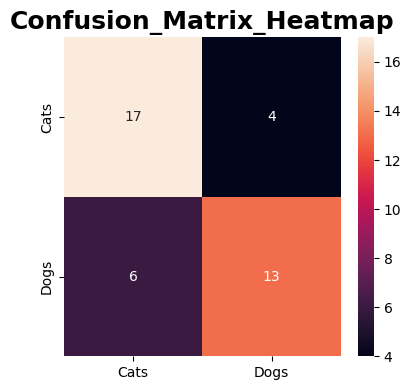

In [11]:
confusion_matrix_heatmap(Y_test,Y_predicted,['Cats','Dogs'],[0,1])

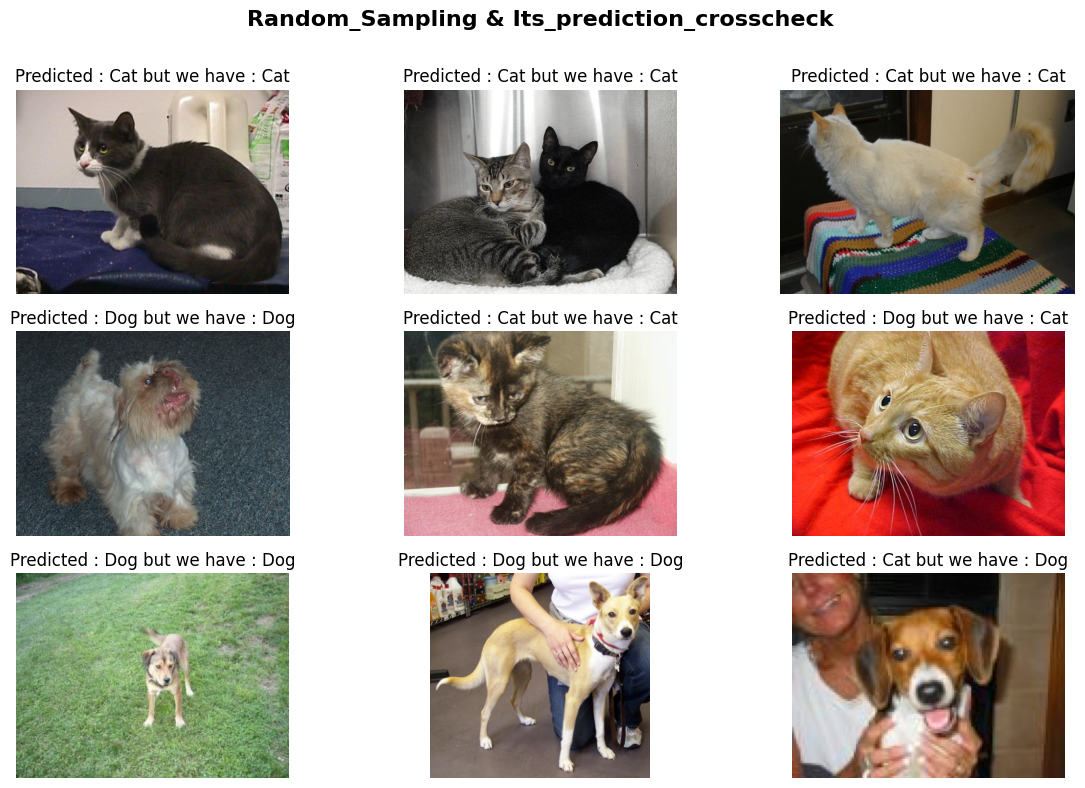

In [12]:
random_sampling(X_test,Y_test,Y_predicted)

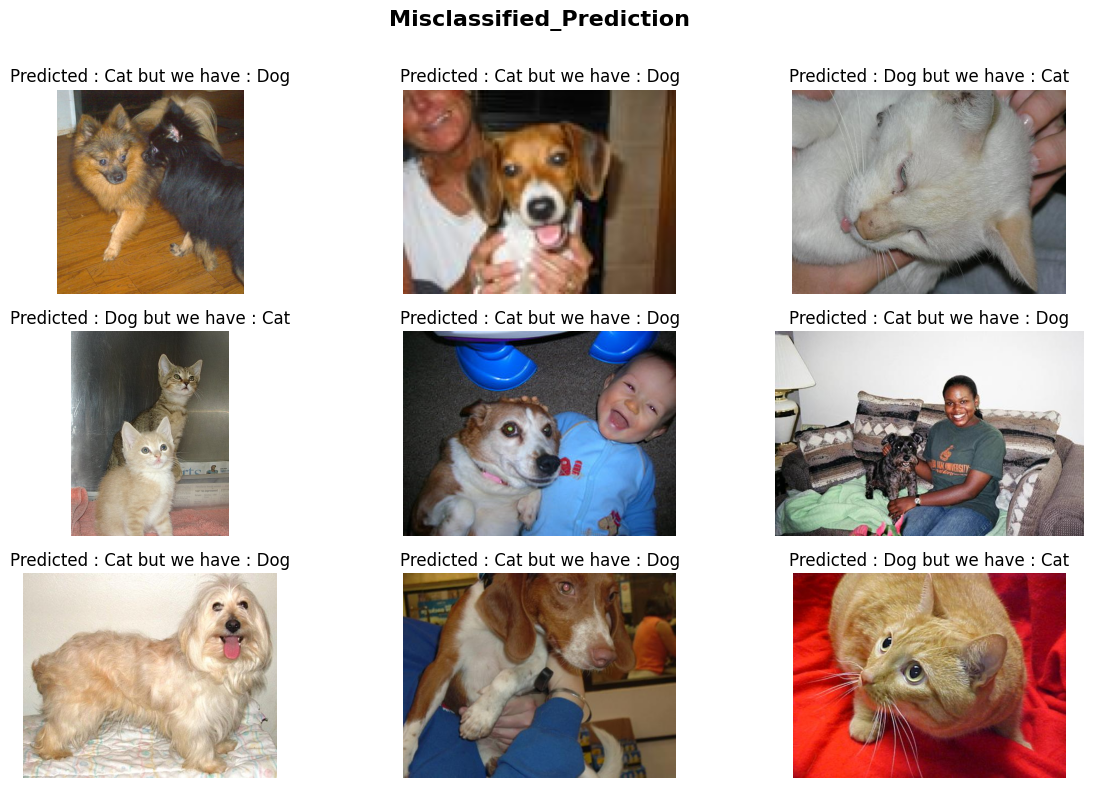

In [13]:
misclassified_sampling()

# But the accuray is too low. Needs Something Different. Keep conncected as it will be posted soon :)
# 

**# Thank You :)**